In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import gzip
import itertools
import os
import pickle
from pathlib import Path

import graphviz
import imageio
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pydot
import seaborn as sns
from PIL import Image

from agentlab.analyze import inspect_results

sns.set_context("notebook") # makes the text in the plots larger, for better visibility
%config InlineBackend.figure_format = 'svg' # makes the plots HD in the notebook
mpl.rcParams["figure.autolayout"] = True # enables tigh layout. Better multiplots
plt.rcParams['font.family'] = 'sans-serif'

# Constants

In [3]:
TASK_NAME_PREFIX ="workarena.servicenow."
OFFSET = len(TASK_NAME_PREFIX)
TECHNIQUE = "hpa"
PKL_PREFIX = "step_"
PKL_SUFFIX = ".pkl.gz"
PKL_PATTERN = f"{PKL_PREFIX}*{PKL_SUFFIX}"

# DATA_PATHS = [
#    Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1"),
#    Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps"),
#    Path("/Users/montis/agentlab_results/2026-02-20_16-27-11_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_684"),
#    Path("/Users/montis/agentlab_results/2026-02-24_16-21-01_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_773"),
#    Path("/Users/montis/agentlab_results/2026-03-05_19-19-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_815"),
#    Path("/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903"),
#    Path("/Users/montis/agentlab_results/2026-02-26_17-02-54_hpaagent-openai-gpt-5-on-workarena-l1")
#    Path("/Users/montis/agentlab_results/2026-03-04_18-27-52_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-task-name-workarena-servicenow-single-chart-value-retrieval")
#    Path("/Users/montis/agentlab_results/2026-03-04_18-49-17_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-tree-update-review")
# ] # Paths to the data.

TASK_CATEGORIES_PATH = Path("tasks_categories.csv")
TASK_CATEGORIES = pd.read_csv(TASK_CATEGORIES_PATH)
hpa_path = Path("/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903")
baseline_path = Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps")

# Processing

In [4]:
def read_raw_data_and_reset_index(data_path: str) -> pd.DataFrame:
    df = inspect_results.load_result_df(data_path)
    df = df.reset_index()
    return df

def compute_accuracy(df: pd.DataFrame) -> float:
    return df["cum_reward"].mean() * 100

def get_agent_name_with_accuracy(df: pd.DataFrame) -> str:
    base_agent_name = df["agent.agent_name"].iloc[0]
    accuracy_str = str(compute_accuracy(df).round(1))
    return f"{base_agent_name}_{accuracy_str}"

def add_tree_evolution_to_dataframe(df: pd.DataFrame) -> list[dict]:
    tree_evolution_list = []
    for _, row in df.iterrows():
        exp_dir = Path(row["exp_dir"])
        pkl_file_list = list(exp_dir.glob(PKL_PATTERN))
        pkl_file_list.sort(key=lambda x: int(Path(x.stem).stem.split("_")[-1]))
        tree_evolution = {}
        for index, pkl_file in enumerate(pkl_file_list):
            with gzip.open(pkl_file, "rb") as f:
                obj = pickle.load(f)
                if hasattr(obj.agent_info, "extra_info"):
                    tree_evolution[f"{PKL_PREFIX}{index}"] = obj.agent_info.extra_info["hpa_plan"]
        tree_evolution_list.append(tree_evolution)
    return tree_evolution_list

def count_retries(tree_evolution: dict) -> int:
    n_retries = 0
    last_depth_4 = 0

    for step in tree_evolution.values():
        current_depth_4 = step["tree_counts"]["by_depth"].get("4", 0)
        if current_depth_4 > last_depth_4:
            n_retries += 1
            last_depth_4 = current_depth_4
    return n_retries

def preprocess_raw_data(df: pd.DataFrame, is_genericagent: bool = False, save_csv: bool = False) -> pd.DataFrame:
    preprocessed_df = df.copy()
    agent_name_with_accuracy = get_agent_name_with_accuracy(preprocessed_df)
    task_lookup = dict(zip(TASK_CATEGORIES["task_name"], TASK_CATEGORIES["category"]))
    preprocessed_df["env.task_name"] = [task_name[OFFSET:] for task_name in preprocessed_df["env.task_name"]]
    preprocessed_df["model"] = [agent_name_with_accuracy] * len(preprocessed_df)
    preprocessed_df["task_category"] = preprocessed_df["env.task_name"].map(lambda x: task_lookup.get(x, "Unknown"))
    if not is_genericagent:
        preprocessed_df["tree_evolution"] = add_tree_evolution_to_dataframe(preprocessed_df)
        preprocessed_df["pruned_nodes"] = preprocessed_df["tree_evolution"].apply(
            lambda x: sum(len(step["tree_update"]["prune"]) for step in x.values())
        )
        preprocessed_df["task_retries"] = preprocessed_df["tree_evolution"].apply(count_retries)
    if save_csv:
        preprocessed_df.to_csv(f"preprocessed_{agent_name_with_accuracy}.csv")
    return preprocessed_df

def aggregate_by_task_name_and_compute_statistics(df: pd.DataFrame, is_genericagent: bool = False) -> pd.DataFrame:
    """
    Compute the statistics grouping the databy task name
    """
    if not is_genericagent:
        aggregated_df = df.groupby(["env.task_name", "task_category", "model"]).agg(
            avg_cum_reward=("cum_reward", "mean"),
            avg_n_steps=("n_steps", "mean"),
            median_pruned=("pruned_nodes", "median"),
            avg_task_retries=("task_retries", "mean"),
        ).reset_index()
    else:
        aggregated_df = df.groupby(["env.task_name", "task_category", "model"]).agg(
            avg_cum_reward=("cum_reward", "mean"),
            avg_n_steps=("n_steps", "mean"),
        ).reset_index()
    return aggregated_df

def compute_relative_aggregated_statistics(aggregated_df: pd.DataFrame, aggregated_baseline_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the statistics relative to the baseline and aggregated by task name
    """
    aggregated_df = aggregated_df.sort_values(by="env.task_name")
    aggregated_baseline_df = aggregated_baseline_df.sort_values(by="env.task_name")
    aggregated_df["relative_cum_reward"] = (aggregated_df["avg_cum_reward"] - aggregated_baseline_df["avg_cum_reward"]) / aggregated_baseline_df["avg_cum_reward"] * 100
    aggregated_df["relative_n_steps"] = (aggregated_df["avg_n_steps"] - aggregated_baseline_df["avg_n_steps"]) / aggregated_baseline_df["avg_n_steps"] * 100
    return aggregated_df

def filter_and_sort_by_median_pruned(df: pd.DataFrame, median_threshold: int = 0) -> pd.DataFrame:
    """
    Filter and sort the dataframe by the median number of pruned nodes using a threshold
    """
    filtered_df = df[df["median_pruned"] > median_threshold]
    return filtered_df.sort_values("median_pruned")

def prepare_oracle_data(df: pd.DataFrame):
    oracle_df = df.rename(columns={"category": "task_category", "task_name": "env.task_name", "avg_n_actions": "avg_n_steps", "std_n_actions": "std_n_steps"})
    oracle_df["model"] = ["Oracle"] * len(oracle_df)
    high_bounds = oracle_df.copy()
    high_bounds['n_steps'] = oracle_df['avg_n_steps'] + oracle_df['std_n_steps']
    
    low_bounds = oracle_df.copy()
    low_bounds['n_steps'] = oracle_df['avg_n_steps'] - oracle_df['std_n_steps']

    combined_oracle_df = pd.concat([high_bounds, low_bounds]).reset_index(drop=True)
    return combined_oracle_df

# Data Visualization

In [5]:
def plot_combined_reward_step_count(df: pd.DataFrame, save: bool = False):
    # Set up the figure with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
    sorted_df = df.sort_values(by=["model", "cum_reward"], ascending=[False, True])

    # Left Plot: Average Reward
    sns.barplot(
        data=sorted_df,
        x="cum_reward",
        y="env.task_name",
        hue="model",
        ax=ax1,
        orient='h',
        errorbar=None,
    )
    ax1.set_xlabel("Average Reward")
    ax1.set_ylabel("Task Name")
    ax1.grid(True, axis="x", linestyle="--", linewidth=0.5)

    # Right Plot: Average Step Count
    sns.barplot(
        data=sorted_df,
        x="n_steps",
        y="env.task_name",
        hue="model",
        ax=ax2,
        orient='h',
        errorbar=None,
    )
    ax2.set_xlabel("Average Step Count")
    ax2.set_ylabel("")  # Hide y-label as it's shared with the left plot
    ax2.grid(True, axis="x", linestyle="--", linewidth=0.5)
    ax2.axvline(x=15, linestyle="--", color="red", linewidth=1)
    ax2.set_xlim(0, 30)

    # Unified legend
    handles, labels = ax1.get_legend_handles_labels()
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    
    fig.legend(handles, labels, loc='upper center', title="Model", bbox_to_anchor=(0.5, 0.95))

    # Draw spines
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    # Title and Layout
    # plt.suptitle(f"Agent Performance: Baseline vs {TECHNIQUE.upper()}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.85]) # Leave room for the suptitle

    if save:
        models_str = '_'.join(df.model.unique())
        plt.savefig(Path(f"plots/combined_metrics_{models_str}.png"), bbox_inches="tight", dpi=200)
    
    plt.show()

def plot_combined_reward_step_count_filtered(df_list: list[pd.DataFrame], threshold: float = 0.05, save: bool = False):
    # Ensure we have exactly 2 dataframes to compare for a 2x2 plot (permutations of 2 is 2)
    sorted_df_list = [df.sort_values(by="env.task_name").reset_index(drop=True) for df in df_list]
    model_permutations = list(itertools.permutations(sorted_df_list, 2))
    
    # Set up the figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # Flatten or structure axes for easy access
    ax_pairs = [(axes[0, 0], axes[0, 1]), (axes[1, 0], axes[1, 1])]

    for i, (model_left, model_right) in enumerate(model_permutations):
        if i >= 2: 
            break # Limit to 2 rows based on subplot definition
        
        # Calculate mask based on threshold comparison
        diff = model_left["avg_cum_reward"].values - model_right["avg_cum_reward"].values
        mask = diff >= threshold
        
        filtered_model_left = model_left[mask]
        filtered_model_right = model_right[mask]
        filtered_df = pd.concat([filtered_model_left, filtered_model_right]).sort_values(by=["model", "avg_cum_reward"], ascending=[False, True]).reset_index(drop=True)

        if filtered_df.empty:
            print(f"No tasks exceeded the threshold for permutation {i}")
            continue

        # Left Plot: Average Reward
        sns.barplot(
            data=filtered_df,
            x="avg_cum_reward",
            y="env.task_name",
            hue="model",
            ax=ax_pairs[i][0],
            orient='h',
            errorbar=None,
        )
        ax_pairs[i][0].set_xlabel("Average Reward")
        ax_pairs[i][0].set_ylabel("Task Name")
        ax_pairs[i][0].grid(True, axis="x", linestyle="--", alpha=0.6)

        # Right Plot: Average Step Count
        sns.barplot(
            data=filtered_df,
            x="avg_n_steps",
            y="env.task_name",
            hue="model",
            ax=ax_pairs[i][1],
            orient='h',
            errorbar=None,
        )
        ax_pairs[i][1].set_xlabel("Average Step Count")
        ax_pairs[i][1].set_ylabel("") 
        ax_pairs[i][1].grid(True, axis="x", linestyle="--", alpha=0.6)
        ax_pairs[i][1].axvline(x=15, linestyle="--", color="red", linewidth=1)
        ax_pairs[i][1].set_xlim(0, 30)

        # Cleanup individual legends
        ax_pairs[i][0].get_legend().remove()
        ax_pairs[i][1].get_legend().remove()

    # Global Legend logic
    handles, labels = ax_pairs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', title="Model", bbox_to_anchor=(0.5, 0.98), ncol=2)

    # Styling
    for ax in axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save and not filtered_df.empty:
        models_str = '_'.join(filtered_df['model'].unique().astype(str))
        save_path = Path(f"plots/combined_metrics_{models_str}.png")
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    
    plt.show()

def plot_model_heatmap(df: pd.DataFrame, save: bool = False):
    # Prepare data
    pivoted_df = df.pivot(
        index="env.task_name", 
        columns="avg_cum_reward", 
        values="avg_n_steps"
    )

    plt.figure(figsize=(9, 6))

    # Calculate bounds for the colorbar
    min_val = np.floor(df["avg_n_steps"].min())
    max_val = np.ceil(df["avg_n_steps"].max())

    # Create the heatmap
    g = sns.heatmap(
        pivoted_df, 
        vmin=min_val,
        vmax=max_val,
        cmap="Spectral_r",
        cbar_kws={'label': 'Average Number of Steps'},
    )

    # Colorbar Formatting
    cbar = g.collections[0].colorbar
    tick_locations = np.linspace(min_val, max_val, num=5)
    cbar.set_ticks(tick_locations)
    cbar.set_ticklabels([f"{int(x)}" for x in tick_locations])

    # Axis formatting
    g.set_yticks(np.arange(len(pivoted_df.index)) + 0.5)
    g.set_yticklabels(pivoted_df.index, rotation=0)
    # g.set_xlim(0, 1.05)
    # g.set_xticks(np.arange(0, 1.05, 0.1))
    # g.set_xticklabels([f"{x:.1f}" for x in np.arange(0, 1.05, 0.1)])

    g.set_title(f"{df['model'].iloc[0]} Heatmap", pad=20, fontsize=14)
    g.set(xlabel="Average Cumulative Reward", ylabel="Task Name")

    for spine in g.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
    
    plt.tight_layout()

    if save:
        plt.savefig(Path(f"plots/heatmap_{df['model'].iloc[0]}.png"), bbox_inches="tight", dpi=200)

def visualize_retried_tasks(df: pd.DataFrame, max_depth: int = 4) -> None:
    # Select only the rows of the dataframe where the tree_counts.max_depth_reached is 4
    mask = [
        any(step["tree_counts"]["max_depth_reached"] == max_depth for step in row_val.values())
        for row_val in df["tree_evolution"]
    ]
    retried_tasks_df = df[mask].copy()
    # Sort task names in ascending order by the median of the cumulative rewards
    task_rank = (
        retried_tasks_df.groupby("env.task_name")["cum_reward"]
        .sum()
        .sort_values(ascending=True)
        .index
    )
    retried_tasks_df["env.task_name"] = pd.Categorical(
        retried_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the histogram
    plt.figure(figsize=(10, 6))
    g = sns.histplot(
        data=retried_tasks_df,
        y="env.task_name",
        hue="cum_reward",
        multiple="stack",
        discrete=True,
        shrink=0.8,
    )

    g.set_xlabel("Tasks Count")
    g.set_ylabel("Task Name")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()


def visualize_pruned_tasks(df: pd.DataFrame, median_threshold: int = 0) -> None:
    # Create a copy of the dataframe to avoid modifying the original one
    df_copy = df.copy()
    # Create a new column with the total number of pruned nodes for each row in the dataframe
    total_pruned_list = [
        sum(len(step["tree_update"]["prune"]) for step in row_val.values())
        for row_val in df_copy["tree_evolution"]
    ]
    df_copy["total_pruned"] = total_pruned_list
    # Filter the dataframe to only include tasks with a median number of pruned nodes greater than the threshold. Median is used for robustness against outliers.
    pruned_tasks_df = df_copy[
        df_copy.groupby("env.task_name")["total_pruned"].transform("median") > median_threshold
    ].copy()
    # Sort the tasks by the median number of pruned nodes in ascending order
    task_rank = (
        pruned_tasks_df.groupby("env.task_name")["total_pruned"]
        .median()
        .sort_values(ascending=True)
        .index
    )
    pruned_tasks_df["env.task_name"] = pd.Categorical(
        pruned_tasks_df["env.task_name"], categories=task_rank, ordered=True
    )
    # Plot the bar plot
    plt.figure(figsize=(8, 5))
    g = sns.barplot(
        pruned_tasks_df,
        y="env.task_name",
        x="total_pruned",
        estimator="median",
        err_kws={"linewidth": 0.8},
    )
    g.set_xlabel("Median Pruned Nodes")
    g.set_ylabel("Task Name")
    g.grid(axis="x", linestyle="--", alpha=0.5, linewidth=0.8)
    plt.show()

def plot_correlation(df: pd.DataFrame, is_genericagent: bool = False, relative_to_baseline: bool = False):
    """Heatmap of metric correlations."""
    plt.figure(figsize=(8, 6))
    if is_genericagent:
        cols = ['avg_cum_reward', 'avg_n_steps']
    elif (not is_genericagent) and (not relative_to_baseline):
        cols = ['avg_cum_reward', 'avg_n_steps', 'median_pruned', 'avg_task_retries']
    elif (not is_genericagent) and (relative_to_baseline):
        cols = ['relative_cum_reward', 'relative_n_steps', 'median_pruned', 'avg_task_retries']
    corr = df[cols].corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f', square=True)
    plt.title(f'{df["model"].iloc[0]}: correlation between aggregated metrics')
    plt.show()

def plot_average_step_count_vs_oracle(df: pd.DataFrame, save: bool = False):
    oracle_df = prepare_oracle_data(df=TASK_CATEGORIES)
    df = pd.concat([oracle_df, df]).reset_index(drop=True)
    g = sns.catplot(
        data=df.sort_values(by=["model", "n_steps"], ascending=[False, True]),
        x="n_steps",
        y="env.task_name",
        hue="model",
        kind="bar",
        aspect=1.7,
        errorbar="sd",
        capsize=0.2,
        err_kws={
            "linewidth": 0.8,
            "color": "black",
            "alpha": 0.8,
        }
    )
    g.set_axis_labels("Average Step Count", "Task Name")
    g.ax.grid(True, axis="x", linestyle="--", linewidth=0.5)
    plt.axvline(x=15, linestyle="--", color="red", linewidth=1)
    # g.legend.set_title(f"Model {BASELINE_MODEL}")
    plt.xlim(0, 30)
    plt.suptitle(f"Average Step Count, {df.model.unique()[0]} vs {df.model.unique()[1]}")
    plt.subplots_adjust(top=0.93)

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    if save:
        plt.savefig(Path(f"plots/average-step-count_{'_'.join(df.model.unique())}.png"), bbox_inches="tight", dpi=200)

# Tree Visualization

In [6]:
def get_global_layout(data):
    """
    Calculates a single global layout for all nodes present across all steps.
    """
    full_G = nx.DiGraph()
    for step in data.values():
        for node in step["tree_snapshot"]:
            full_G.add_node(node["id"])
            if node["parent_id"]:
                full_G.add_edge(node["parent_id"], node["id"])

    pydot_graph = nx.drawing.nx_pydot.to_pydot(full_G)
    pydot_graph.set_rankdir("LR")

    layout_dot = pydot_graph.create_dot(prog="dot").decode("utf-8")
    positioned_graphs = pydot.graph_from_dot_data(layout_dot)

    if not positioned_graphs:
        return {}, []

    positioned_graph = positioned_graphs[0]
    fixed_pos = {}
    all_node_ids = []

    for node in positioned_graph.get_nodes():
        name = node.get_name().strip('"')
        if name in ("graph", "node", "edge"):
            continue
        pos = node.get_pos()
        if pos:
            clean_pos = pos.replace('"', "")
            fixed_pos[name] = f"{clean_pos}!"
            all_node_ids.append(name)

    return fixed_pos, all_node_ids


def create_fixed_graphviz_step(snapshot, fixed_layout, all_node_ids, title="Tree Step"):
    """
    Renders a snapshot with a modern blue theme and rounded rectangles.
    """
    # CSS-inspired Blue Palette
    type_colors = {
        "OR": "#EBF5FB",  # Extra Light Blue
        "AND": "#AED6F1",  # Light Blue
        "ACTION": "#5DADE2",  # Professional Blue
        "UNKNOWN": "#F4F6F7",  # Ghost White
    }

    status_border_colors = {
        "SUCCESS": "#1B4F72",  # Dark Navy
        "VISITED": "#2E86C1",  # Ocean Blue
        "UNVISITED": "#D6DBDF",  # Silver Blue
    }

    dot = graphviz.Digraph(engine="neato", format="png")
    dot.attr(overlap="false", splines="true", bgcolor="white", pad="0.5")
    dot.attr(
        label=f"\n\n{title}\n",
        labelloc="t",
        fontsize="24",
        fontname="Helvetica-Bold",
        fontcolor="#1B4F72",
    )

    current_nodes = {str(n["id"]): n for n in snapshot}
    current_edges = {(str(n["parent_id"]), str(n["id"])) for n in snapshot if n["parent_id"]}

    for nid in all_node_ids:
        pos = fixed_layout.get(nid)
        if not pos:
            continue

        if nid in current_nodes:
            node_data = current_nodes[nid]
            ntype = node_data["type"]
            status = node_data["status"]

            # Label with ID in small font and Type in Bold
            label = f"""<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2">
                           <TR><TD><FONT POINT-SIZE="9" COLOR="#2E86C1">{nid}</FONT></TD></TR>
                           <TR><TD><B><FONT POINT-SIZE="12" COLOR="#1B4F72">{ntype}</FONT></B></TD></TR>
                        </TABLE>>"""

            # Forcing "rect" and "rounded" for every node
            dot.node(
                nid,
                label=label,
                pos=pos,
                style="filled, rounded",
                fillcolor=type_colors.get(ntype, "#FFFFFF"),
                color=status_border_colors.get(status, "#BDC3C7"),
                penwidth="4" if status == "SUCCESS" else "1.5",
                shape="rect",
                fontname="Helvetica",
            )
        else:
            # Invisible placeholder
            dot.node(nid, label="", pos=pos, style="invis", width="1.0", height="0.6")

    # Draw Edges with a subtle blue-grey color
    for parent, child in current_edges:
        dot.edge(parent, child, color="#AED6F1", penwidth="2", arrowhead="vee")

    return dot


def generate_tree_animation(data, filename="blue_tree_evolution.gif", fps=1):
    temp_folder = "temp_frames"
    if not os.path.exists(temp_folder):
        os.makedirs(temp_folder)

    fixed_layout, all_node_ids = get_global_layout(data)
    images = []
    steps = sorted(data.keys(), key=lambda x: int(x.split("_")[1]))

    print(f"Generating frames for {len(steps)} steps...")

    for i, step_name in enumerate(steps):
        snapshot = data[step_name]["tree_snapshot"]
        gv_graph = create_fixed_graphviz_step(
            snapshot, fixed_layout, all_node_ids, title=f"Exploration: {step_name}"
        )

        frame_base = os.path.join(temp_folder, f"frame_{i:03d}")
        gv_graph.render(frame_base, cleanup=True)

        img = Image.open(f"{frame_base}.png").convert("RGB")
        images.append(np.array(img))

    # Standardize sizes to prevent imageio errors
    max_h = max(im.shape[0] for im in images)
    max_w = max(im.shape[1] for im in images)

    final_frames = []
    for im in images:
        if im.shape[0] != max_h or im.shape[1] != max_w:
            new_im = Image.new("RGB", (max_w, max_h), (255, 255, 255))
            new_im.paste(Image.fromarray(im), (0, 0))
            final_frames.append(np.array(new_im))
        else:
            final_frames.append(im)

    imageio.mimsave(filename, final_frames, fps=fps, loop=0)
    print(f"Done! Animation saved as: {filename}")

    # Cleanup
    for f in os.listdir(temp_folder):
        os.remove(os.path.join(temp_folder, f))
    os.rmdir(temp_folder)

# Run Processing

In [7]:
raw_baseline = read_raw_data_and_reset_index(data_path=baseline_path)
raw_hpa = read_raw_data_and_reset_index(data_path=hpa_path)

Loading results: 100%|██████████| 330/330 [00:00<00:00, 587.39it/s]


In [8]:
preprocessed_baseline = preprocess_raw_data(df=raw_baseline, is_genericagent=True)
preprocessed_hpa = preprocess_raw_data(df=raw_hpa, is_genericagent=False)

In [9]:
preprocessed_concat = pd.concat([preprocessed_baseline, preprocessed_hpa]).reset_index(drop=True)

In [10]:
aggregated_baseline = aggregate_by_task_name_and_compute_statistics(preprocessed_baseline, is_genericagent=True)
aggregated_hpa = aggregate_by_task_name_and_compute_statistics(preprocessed_hpa, is_genericagent=False)
aggregated_hpa = compute_relative_aggregated_statistics(aggregated_hpa, aggregated_baseline)

# Run Visualization

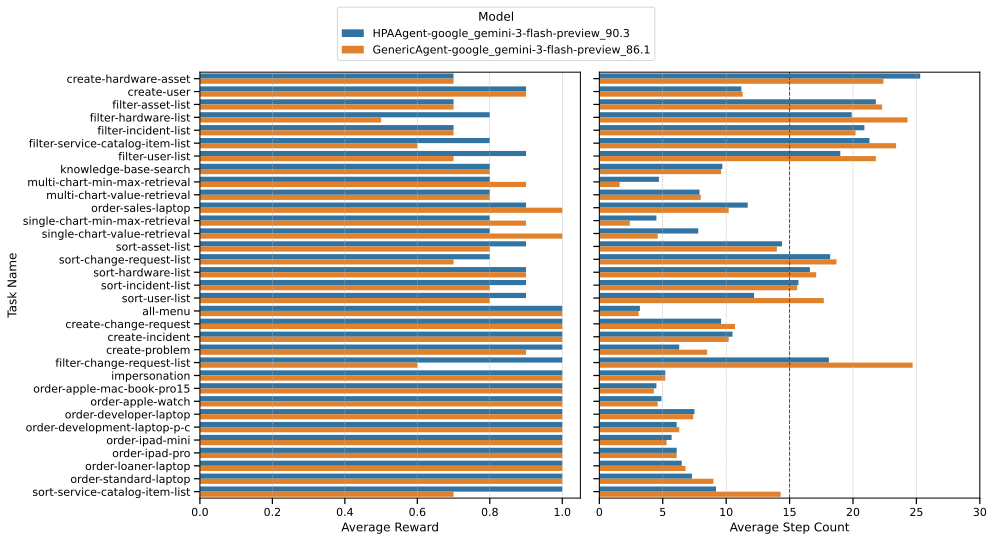

In [11]:
plot_combined_reward_step_count(preprocessed_concat)

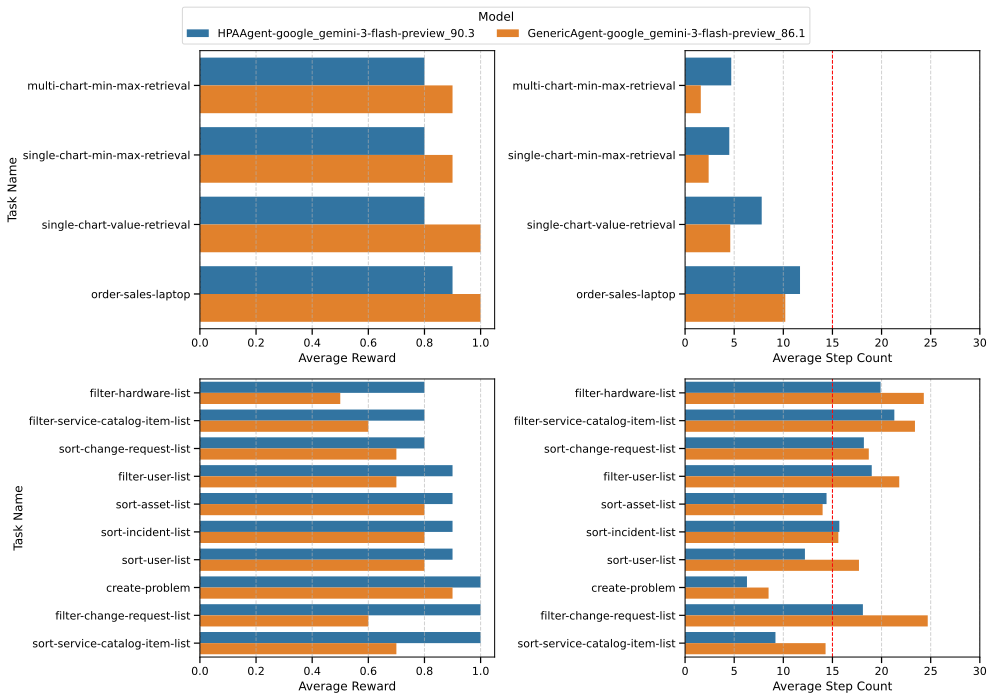

In [12]:
plot_combined_reward_step_count_filtered(df_list=[aggregated_baseline, aggregated_hpa])

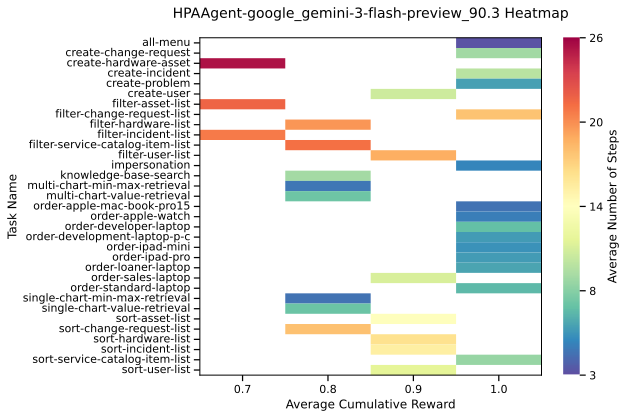

In [13]:
plot_model_heatmap(aggregated_hpa)

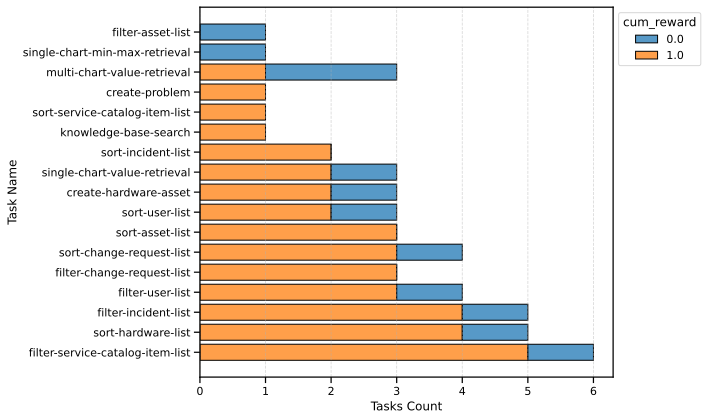

In [14]:
visualize_retried_tasks(df=preprocessed_hpa)

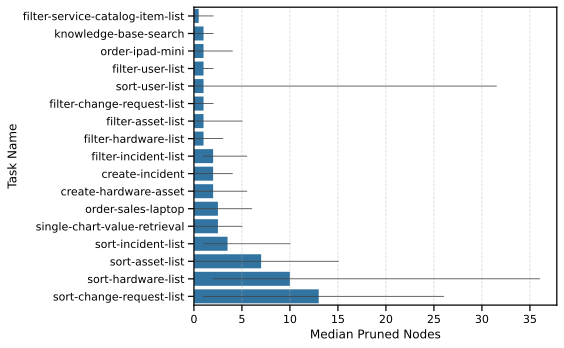

In [15]:
visualize_pruned_tasks(df=preprocessed_hpa)

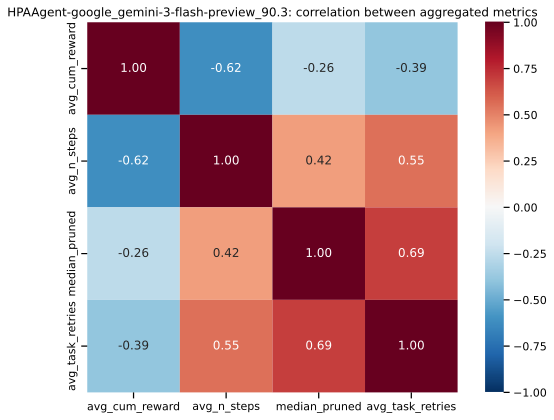

In [16]:
plot_correlation(df=aggregated_hpa, is_genericagent=False)

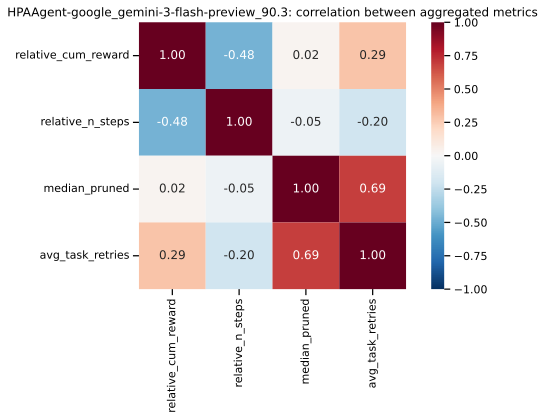

In [18]:
plot_correlation(df=aggregated_hpa, is_genericagent=False, relative_to_baseline=True)

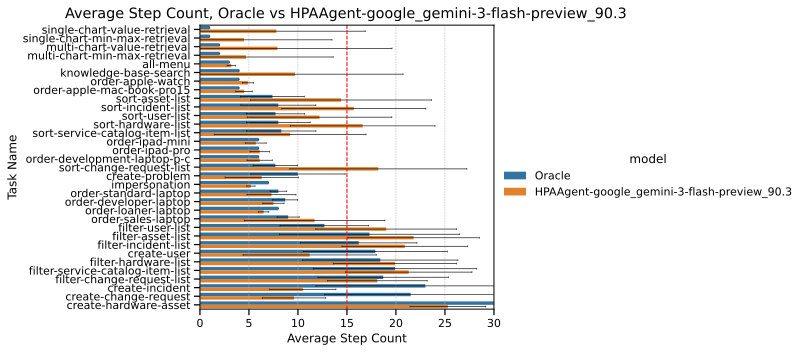

In [25]:
plot_average_step_count_vs_oracle(df=preprocessed_hpa, save=True)

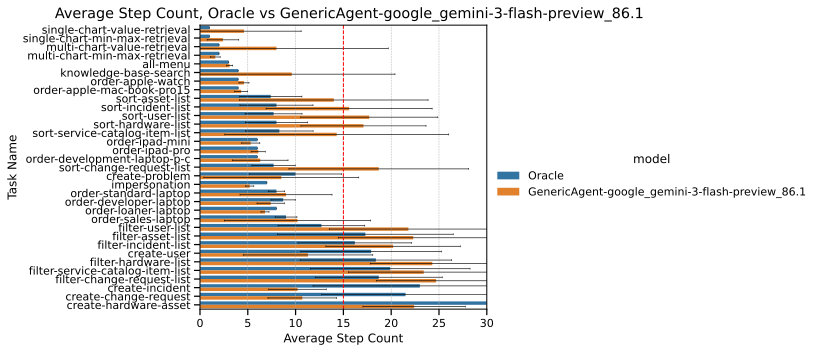

In [20]:
plot_average_step_count_vs_oracle(df=preprocessed_baseline)

# Run Tree Visualization

In [21]:
generate_tree_animation(data=preprocessed_hpa.iloc[33]["tree_evolution"], filename="tree_animation.gif", fps=1)

Generating frames for 13 steps...


Done! Animation saved as: tree_animation.gif
